# Reading and Converting Data with Simpyson

This tutorial covers the data handling capabilities of `simpyson`, including reading SIMPSON output files, converting VASP DFT calculations, and using the graphical user interface.

## 1. Reading SIMPSON Output Files

`simpyson` can read `.spe` (spectrum), `.fid` (time-domain), and `.xreim` files generated by SIMPSON. The core function for this is `read_simp`.

In [ ]:
from __future__ import annotations

import matplotlib.pyplot as plt

from simpyson.io import read_simp

# Path to example file
filename = '../../examples/read/ethanol.spe'

# Read the file. We specify B0 and nucleus to correctly calculate the ppm scale.
data = read_simp(filename, b0='400MHz', nucleus='1H')

print(f"Loaded data type: {type(data)}")
print(f"Spectral Width: {data.spe['sw']} Hz")

Loaded data type: <class 'simpyson.simpy.Simpy'>
Spectral Width: 10000.0 Hz


The returned object is a `Simpy` object. It automatically handles conversion between time domain (FID) and frequency domain (Spectrum) via Fast Fourier Transform (FFT).

You can access the data arrays directly using `.spe` (spectrum) or `.fid` (time-domain) attributes. The ppm scale is available in `data.ppm`.

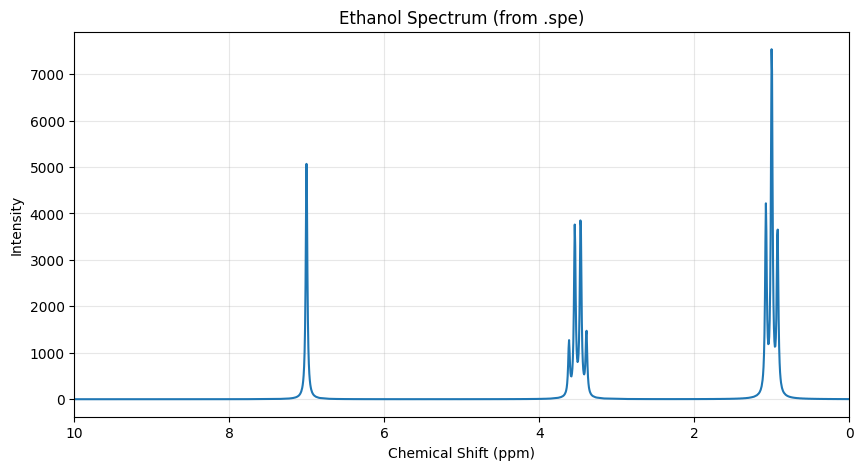

In [2]:
# Plotting the spectrum
plt.figure(figsize=(10, 5))
plt.plot(data.ppm['ppm'], data.ppm['real'])
plt.xlim(10, 0)  # Standard NMR convention: high ppm to low ppm
plt.xlabel("Chemical Shift (ppm)")
plt.ylabel("Intensity")
plt.title("Ethanol Spectrum (from .spe)")
plt.grid(True, alpha=0.3)
plt.show()

## 2. Converting DFT Calculation Outputs (VASP)

Simpyson can parse VASP `OUTCAR` files to extract NMR parameters like chemical shielding tensors and Electric Field Gradients (EFG). Use `read_vasp` for this, that creates a ASE `Atoms` object containing the magnetic shielding and efg tensor under atoms.arrays['ms'] and atoms.arrays['efg'], similar to `Magres` files.

In [12]:
from simpyson.converter import read_vasp

# Path to example OUTCAR
vasp_file = '../../examples/write/AlPO-14.OUTCAR'

atoms = read_vasp(vasp_file, format='vasp-out')

# Print first four ms and efg tensors
print('Example of magnetic shielding tensors')
print(f"{atoms.arrays['ms'][:4]}")
print('\n')
print('Example of electric field gradient tensors')
print(f"{atoms.arrays['efg'][:4]}")


Example of magnetic shielding tensors
[[[513.46414237  10.495471    -1.140594  ]
  [ 18.453975   526.66315637 -13.976764  ]
  [  1.644529    -6.971756   503.19928237]]

 [[513.46414037  10.495462    -1.140558  ]
  [ 18.453986   526.66312437 -13.976699  ]
  [  1.644553    -6.971697   503.19930437]]

 [[522.30905637   1.754984    -4.475608  ]
  [ -0.884285   522.69452937  -1.442856  ]
  [ -4.056453    -6.352893   519.71053537]]

 [[522.30892937   1.75501     -4.475581  ]
  [ -0.884298   522.69448537  -1.442817  ]
  [ -4.056418    -6.3529     519.71048237]]]


Example of electric field gradient tensors
[[[ 0.01443807 -0.07187135  0.01989223]
  [-0.07187135 -0.06324762  0.05085742]
  [ 0.01989223  0.05085742  0.04881983]]

 [[ 0.01443807 -0.07187135  0.01989223]
  [-0.07187135 -0.06324762  0.05085742]
  [ 0.01989223  0.05085742  0.04880954]]

 [[-0.00222283  0.00824298  0.07168612]
  [ 0.00824298  0.00685371  0.00359151]
  [ 0.07168612  0.00359151 -0.00464118]]

 [[-0.00222283  0.00825327 

## 3. Graphical User Interface (GUI)

Simpyson includes a GUI for quick inspection and simple conversions. You can launch it from the command line:

```bash
simpyson gui
```

Or with a specific file to open immediately:

```bash
simpyson gui path/to/file.spe
```

The GUI allows you to:
- View FID and Spectra
- Apply basic processing (Line Broadening, Phase correction)
- Export data to different formats